# Experimento de 140 combinaciones, parte 2: clasificación

Resultados de las 108 combinaciones aplicables de clasificación (7 modelos × 4 balanceos × 4 optimizadores, menos KNN con `class_weight`).
Todas las métricas salen de los 5 pliegues externos por bloques espaciales, que no participaron en la elección de hiperparámetros.
El diseño está en `Experimento_1_Diseno.ipynb`.

Para mostrar el mejor caso de cada modelo se elige la combinación de balanceo y optimizador con mejor puntaje interno. Elegirla con la
prueba externa y reportar esa misma prueba volvería a meter el sesgo de selección que la validación anidada quita (Cawley y Talbot, 2010).

## Flujo del experimento

![Flujo del experimento](fig_pipeline_experimento.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from src import analisis, config, evaluate, models

maestra, res = analisis.cargar()
clf = res[res.tarea == "clf"]
b = analisis.base()
y = b.y_clf
ORDEN = [m for m in models.MODELOS["clf"] if m in set(clf.modelo)]
print(f"Combinaciones completas de clasificación: {len(clf)} de 108 | modelos: {ORDEN}")

C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Combinaciones completas de clasificación: 108 de 108 | modelos: ['KNN', 'Naive Bayes', 'Regresión logística', 'Árbol de decisión', 'Random Forest', 'XGBoost', 'SVM RBF']


## 1. Las combinaciones, una por una

F1 macro externo medio (y su desviación estándar entre los 5 pliegues). El F1 macro promedia el F1 de las tres clases y es la métrica con la
que se eligen los hiperparámetros: la clase Baja es el 3 % y la exactitud premiaría ignorarla.

In [2]:
def tabla(metrica):
    m = clf.pivot_table(index=["modelo", "balanceo"], columns="optimizador", values=metrica)
    d = clf.pivot_table(index=["modelo", "balanceo"], columns="optimizador", values=metrica + "_de")
    t = m.round(3).astype(str) + " ± " + d.round(3).astype(str)
    return t.reindex(ORDEN, level=0)[[c for c in ["grilla", "aleatoria", "bayesiana", "genetica"] if c in t.columns]]

tabla("f1_macro")

optimizador                              grilla      aleatoria      bayesiana  \
modelo              balanceo                                                    
KNN                 adasyn        0.762 ± 0.018  0.762 ± 0.018  0.762 ± 0.018   
                    ninguno       0.797 ± 0.024  0.799 ± 0.023  0.799 ± 0.023   
                    smote         0.771 ± 0.019  0.771 ± 0.019  0.771 ± 0.019   
Naive Bayes         adasyn        0.464 ± 0.059  0.464 ± 0.059   0.465 ± 0.06   
                    class_weight  0.464 ± 0.049  0.464 ± 0.049  0.465 ± 0.051   
                    ninguno       0.575 ± 0.025  0.576 ± 0.028   0.58 ± 0.025   
                    smote         0.469 ± 0.052  0.469 ± 0.053   0.47 ± 0.053   
Regresión logística adasyn        0.587 ± 0.019  0.587 ± 0.016   0.586 ± 0.02   
                    class_weight  0.629 ± 0.015  0.629 ± 0.014  0.629 ± 0.014   
                    ninguno         0.6 ± 0.013    0.6 ± 0.013    0.6 ± 0.013   
                    smote         0.629 ± 0.014  0.629 ± 0.014  0.629 ± 0.014   
Árbol de decisión   adasyn        0.824 ± 0.024  0.818 ± 0.028  0.828 ± 0.016   
                    class_weight  0.842 ± 0.015  0.863 ± 0.014   0.862 ± 0.02   
                    ninguno       0.868 ± 0.011   0.88 ± 0.014  0.881 ± 0.017   
                    smote         0.852 ± 0.016  0.866 ± 0.019  0.867 ± 0.018   
Random Forest       adasyn        0.874 ± 0.015  0.872 ± 0.015  0.871 ± 0.016   
                    class_weight   0.88 ± 0.015  0.884 ± 0.015  0.887 ± 0.015   
                    ninguno       0.893 ± 0.013  0.894 ± 0.014  0.893 ± 0.016   
                    smote         0.883 ± 0.014  0.883 ± 0.016  0.883 ± 0.015   
XGBoost             adasyn        0.869 ± 0.011  0.875 ± 0.011  0.868 ± 0.012   
                    class_weight   0.88 ± 0.012  0.884 ± 0.014  0.884 ± 0.013   
                    ninguno       0.883 ± 0.017  0.888 ± 0.014  0.888 ± 0.016   
                    smote         0.877 ± 0.012  0.881 ± 0.013  0.883 ± 0.013   
SVM RBF             adasyn        0.735 ± 0.019  0.739 ± 0.016   0.734 ± 0.02   
                    class_weight  0.792 ± 0.014   0.79 ± 0.022   0.79 ± 0.016   
                    ninguno       0.813 ± 0.018  0.815 ± 0.017  0.813 ± 0.017   
                    smote         0.788 ± 0.018   0.79 ± 0.019  0.791 ± 0.019   

optimizador                            genetica  
modelo              balanceo                     
KNN                 adasyn        0.762 ± 0.018  
                    ninguno       0.799 ± 0.023  
                    smote         0.771 ± 0.019  
Naive Bayes         adasyn        0.464 ± 0.059  
                    class_weight  0.466 ± 0.052  
                    ninguno        0.58 ± 0.025  
                    smote          0.47 ± 0.053  
Regresión logística adasyn         0.586 ± 0.02  
                    class_weight  0.629 ± 0.014  
                    ninguno         0.6 ± 0.013  
                    smote         0.629 ± 0.014  
Árbol de decisión   adasyn        0.802 ± 0.034  
                    class_weight  0.855 ± 0.009  
                    ninguno       0.875 ± 0.019  
                    smote          0.857 ± 0.02  
Random Forest       adasyn        0.867 ± 0.014  
                    class_weight  0.877 ± 0.013  
                    ninguno       0.893 ± 0.015  
                    smote          0.88 ± 0.014  
XGBoost             adasyn        0.859 ± 0.014  
                    class_weight  0.864 ± 0.014  
                    ninguno       0.881 ± 0.014  
                    smote          0.87 ± 0.014  
SVM RBF             adasyn        0.734 ± 0.019  
                    class_weight  0.788 ± 0.014  
                    ninguno       0.814 ± 0.018  
                    smote         0.789 ± 0.018

In [3]:
tabla("auc_ovr")

optimizador                              grilla      aleatoria      bayesiana  \
modelo              balanceo                                                    
KNN                 adasyn        0.835 ± 0.017  0.835 ± 0.017  0.835 ± 0.017   
                    ninguno       0.928 ± 0.019  0.929 ± 0.012  0.929 ± 0.011   
                    smote         0.853 ± 0.035  0.853 ± 0.035  0.853 ± 0.035   
Naive Bayes         adasyn        0.818 ± 0.024  0.819 ± 0.024  0.821 ± 0.022   
                    class_weight  0.819 ± 0.011  0.819 ± 0.012  0.818 ± 0.012   
                    ninguno       0.838 ± 0.016  0.838 ± 0.016  0.838 ± 0.016   
                    smote         0.816 ± 0.016  0.817 ± 0.015  0.817 ± 0.016   
Regresión logística adasyn        0.863 ± 0.013  0.863 ± 0.012  0.863 ± 0.013   
                    class_weight  0.873 ± 0.008  0.873 ± 0.008  0.873 ± 0.008   
                    ninguno       0.865 ± 0.014  0.865 ± 0.014  0.865 ± 0.014   
                    smote         0.873 ± 0.007  0.873 ± 0.007  0.873 ± 0.007   
Árbol de decisión   adasyn        0.938 ± 0.036  0.952 ± 0.015  0.948 ± 0.012   
                    class_weight  0.921 ± 0.015   0.95 ± 0.008  0.956 ± 0.011   
                    ninguno       0.962 ± 0.007  0.973 ± 0.007  0.972 ± 0.009   
                    smote         0.956 ± 0.016  0.966 ± 0.014  0.969 ± 0.007   
Random Forest       adasyn        0.978 ± 0.008  0.978 ± 0.007  0.977 ± 0.008   
                    class_weight   0.98 ± 0.008   0.98 ± 0.007   0.98 ± 0.008   
                    ninguno       0.981 ± 0.007  0.981 ± 0.007  0.981 ± 0.007   
                    smote         0.979 ± 0.008  0.978 ± 0.007  0.979 ± 0.008   
XGBoost             adasyn        0.977 ± 0.008  0.978 ± 0.008  0.978 ± 0.008   
                    class_weight  0.978 ± 0.007  0.979 ± 0.008  0.979 ± 0.008   
                    ninguno       0.979 ± 0.007   0.98 ± 0.007  0.981 ± 0.007   
                    smote         0.978 ± 0.008  0.979 ± 0.008  0.979 ± 0.008   
SVM RBF             adasyn        0.916 ± 0.011  0.926 ± 0.009   0.922 ± 0.01   
                    class_weight  0.932 ± 0.006  0.924 ± 0.011  0.928 ± 0.015   
                    ninguno       0.931 ± 0.012   0.929 ± 0.01  0.927 ± 0.007   
                    smote          0.931 ± 0.01   0.933 ± 0.01  0.931 ± 0.008   

optimizador                            genetica  
modelo              balanceo                     
KNN                 adasyn         0.87 ± 0.016  
                    ninguno       0.929 ± 0.011  
                    smote         0.881 ± 0.024  
Naive Bayes         adasyn         0.82 ± 0.022  
                    class_weight  0.819 ± 0.012  
                    ninguno       0.837 ± 0.016  
                    smote         0.817 ± 0.016  
Regresión logística adasyn        0.862 ± 0.013  
                    class_weight  0.873 ± 0.008  
                    ninguno       0.865 ± 0.014  
                    smote         0.873 ± 0.007  
Árbol de decisión   adasyn        0.916 ± 0.024  
                    class_weight  0.947 ± 0.012  
                    ninguno        0.96 ± 0.013  
                    smote         0.955 ± 0.013  
Random Forest       adasyn        0.977 ± 0.007  
                    class_weight  0.979 ± 0.007  
                    ninguno       0.981 ± 0.007  
                    smote         0.978 ± 0.008  
XGBoost             adasyn        0.975 ± 0.008  
                    class_weight  0.975 ± 0.009  
                    ninguno       0.978 ± 0.007  
                    smote         0.976 ± 0.008  
SVM RBF             adasyn         0.922 ± 0.01  
                    class_weight  0.934 ± 0.008  
                    ninguno       0.932 ± 0.008  
                    smote         0.932 ± 0.008

## 2. El mejor caso de cada modelo

Métricas externas de la combinación elegida por puntaje interno. Media ± desviación entre pliegues.

In [4]:
mejores = analisis.mejores_por_modelo(res, "clf").reindex(ORDEN)
cols = ["exactitud", "precision_macro", "recall_macro", "f1_macro", "auc_ovr", "kappa_cuad", "exactitud_bal", "f1_baja", "recall_baja", "brier", "ece"]
t = mejores[["balanceo", "optimizador", "puntaje_interno"]].copy()
for c in cols:
    t[c] = mejores[c].round(3).astype(str) + " ± " + mejores[c + "_de"].round(3).astype(str)
t

,balanceo,optimizador,puntaje_interno,exactitud,precision_macro,recall_macro,f1_macro,auc_ovr,kappa_cuad,exactitud_bal,f1_baja,recall_baja,brier,ece
KNN,ninguno,aleatoria,0.783057,0.893 ± 0.005,0.838 ± 0.016,0.77 ± 0.034,0.799 ± 0.023,0.929 ± 0.012,0.751 ± 0.028,0.77 ± 0.034,0.701 ± 0.055,0.634 ± 0.078,0.054 ± 0.005,0.027 ± 0.009
Naive Bayes,ninguno,bayesiana,0.565233,0.713 ± 0.031,0.547 ± 0.02,0.674 ± 0.048,0.58 ± 0.025,0.838 ± 0.016,0.384 ± 0.04,0.674 ± 0.048,0.485 ± 0.038,0.776 ± 0.098,0.126 ± 0.006,0.082 ± 0.021
Regresión logística,smote,bayesiana,0.626092,0.716 ± 0.024,0.587 ± 0.011,0.796 ± 0.012,0.629 ± 0.014,0.873 ± 0.007,0.483 ± 0.024,0.796 ± 0.012,0.514 ± 0.041,0.926 ± 0.04,0.129 ± 0.01,0.068 ± 0.019
Árbol de decisión,ninguno,bayesiana,0.881836,0.932 ± 0.01,0.9 ± 0.015,0.867 ± 0.019,0.881 ± 0.017,0.972 ± 0.009,0.865 ± 0.019,0.867 ± 0.019,0.846 ± 0.02,0.838 ± 0.027,0.035 ± 0.005,0.016 ± 0.01
Random Forest,ninguno,aleatoria,0.892099,0.94 ± 0.009,0.913 ± 0.011,0.88 ± 0.016,0.894 ± 0.014,0.981 ± 0.007,0.88 ± 0.016,0.88 ± 0.016,0.864 ± 0.016,0.862 ± 0.023,0.032 ± 0.005,0.016 ± 0.005
XGBoost,ninguno,bayesiana,0.885716,0.937 ± 0.01,0.905 ± 0.012,0.877 ± 0.018,0.888 ± 0.016,0.981 ± 0.007,0.875 ± 0.018,0.877 ± 0.018,0.853 ± 0.022,0.862 ± 0.025,0.032 ± 0.005,0.017 ± 0.007
SVM RBF,ninguno,genetica,0.811482,0.894 ± 0.006,0.856 ± 0.024,0.785 ± 0.026,0.814 ± 0.018,0.932 ± 0.008,0.76 ± 0.022,0.785 ± 0.026,0.762 ± 0.03,0.721 ± 0.051,0.06 ± 0.003,0.027 ± 0.005


## 3. Matriz de confusión de cada modelo

Con las predicciones fuera de pliegue: cada planta aparece una vez, predicha por el modelo que no la vio. Filas = clase real, normalizado por fila
(la diagonal es el recall de cada clase).

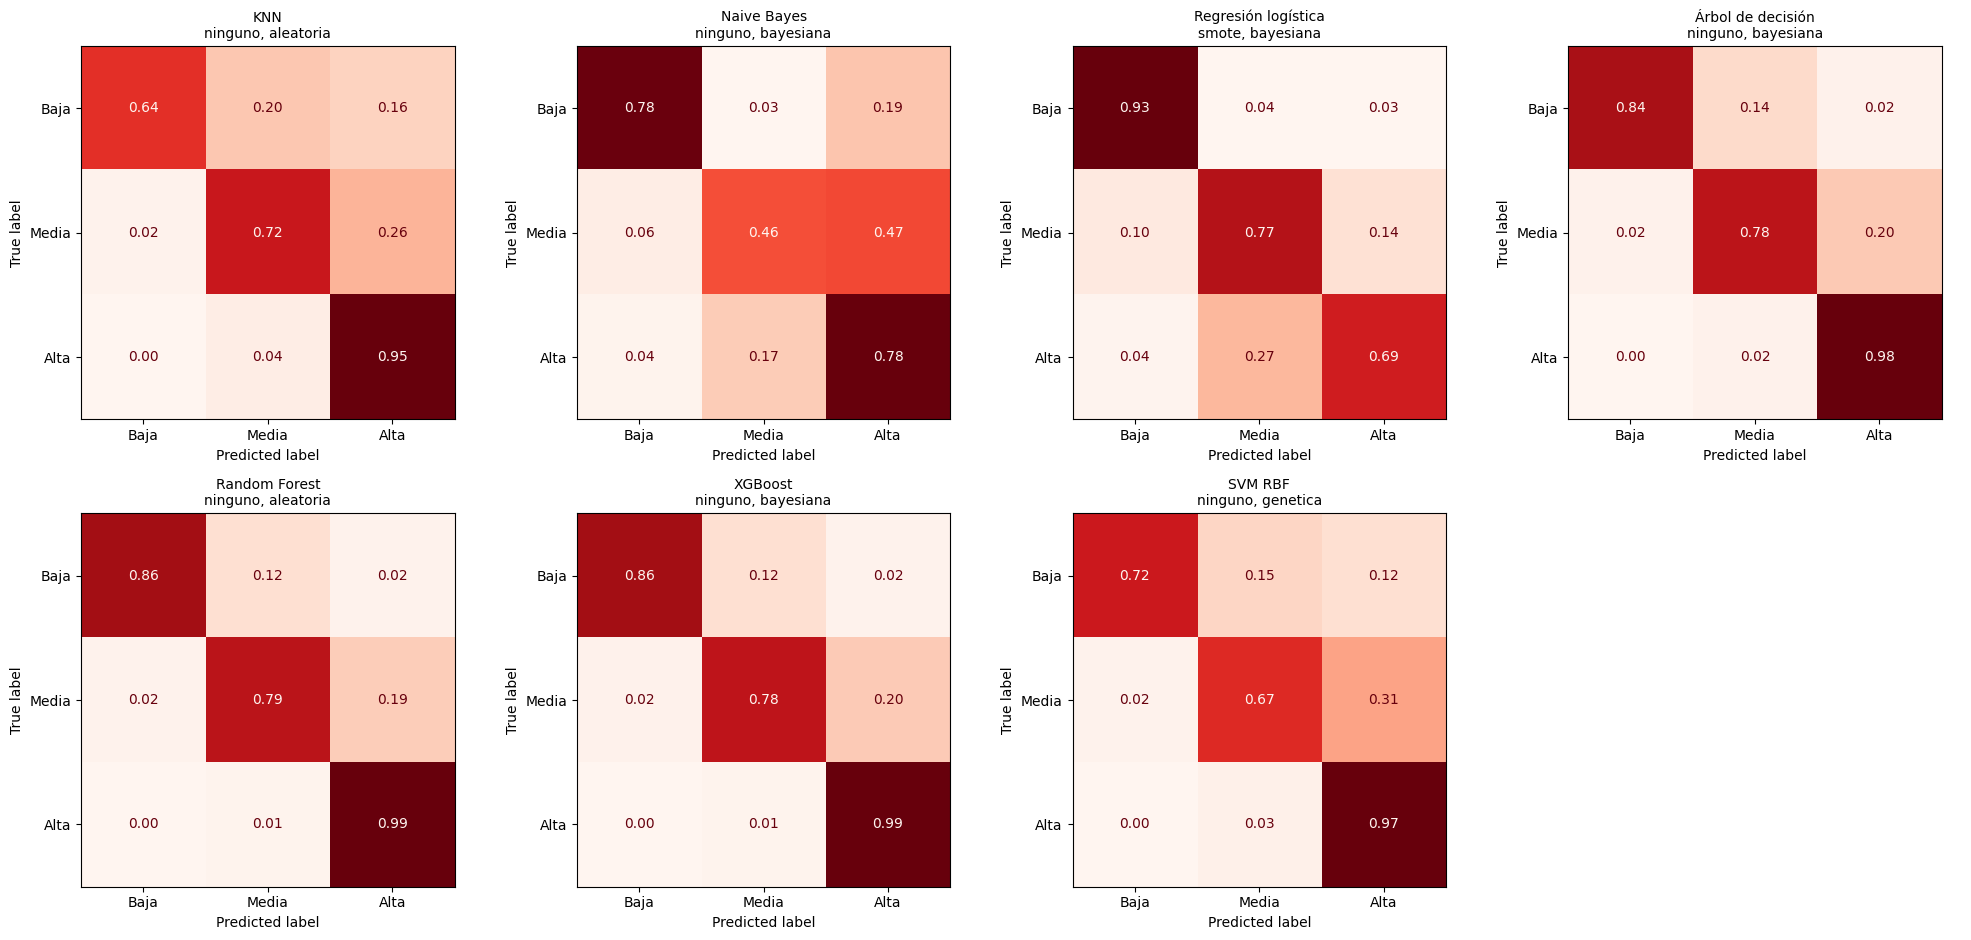

In [5]:
n = len(ORDEN)
fig, axes = plt.subplots(2, 4, figsize=(20, 9.5))
for ax, m in zip(axes.ravel(), ORDEN):
    o = analisis.oof(mejores.loc[m])
    ConfusionMatrixDisplay(confusion_matrix(y, o["pred"].astype(int), normalize="true"), display_labels=config.CLASES).plot(
        ax=ax, values_format=".2f", colorbar=False, cmap="Reds")
    ax.set_title(f"{m}\n{mejores.loc[m, 'balanceo']}, {mejores.loc[m, 'optimizador']}", fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.tight_layout(); fig.savefig("fig_exp_confusion.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Curva ROC de cada modelo

Uno contra el resto, una curva por clase. El AUC mide qué tan bien ordenan las probabilidades a cada clase frente a las otras, sin depender
de un umbral.

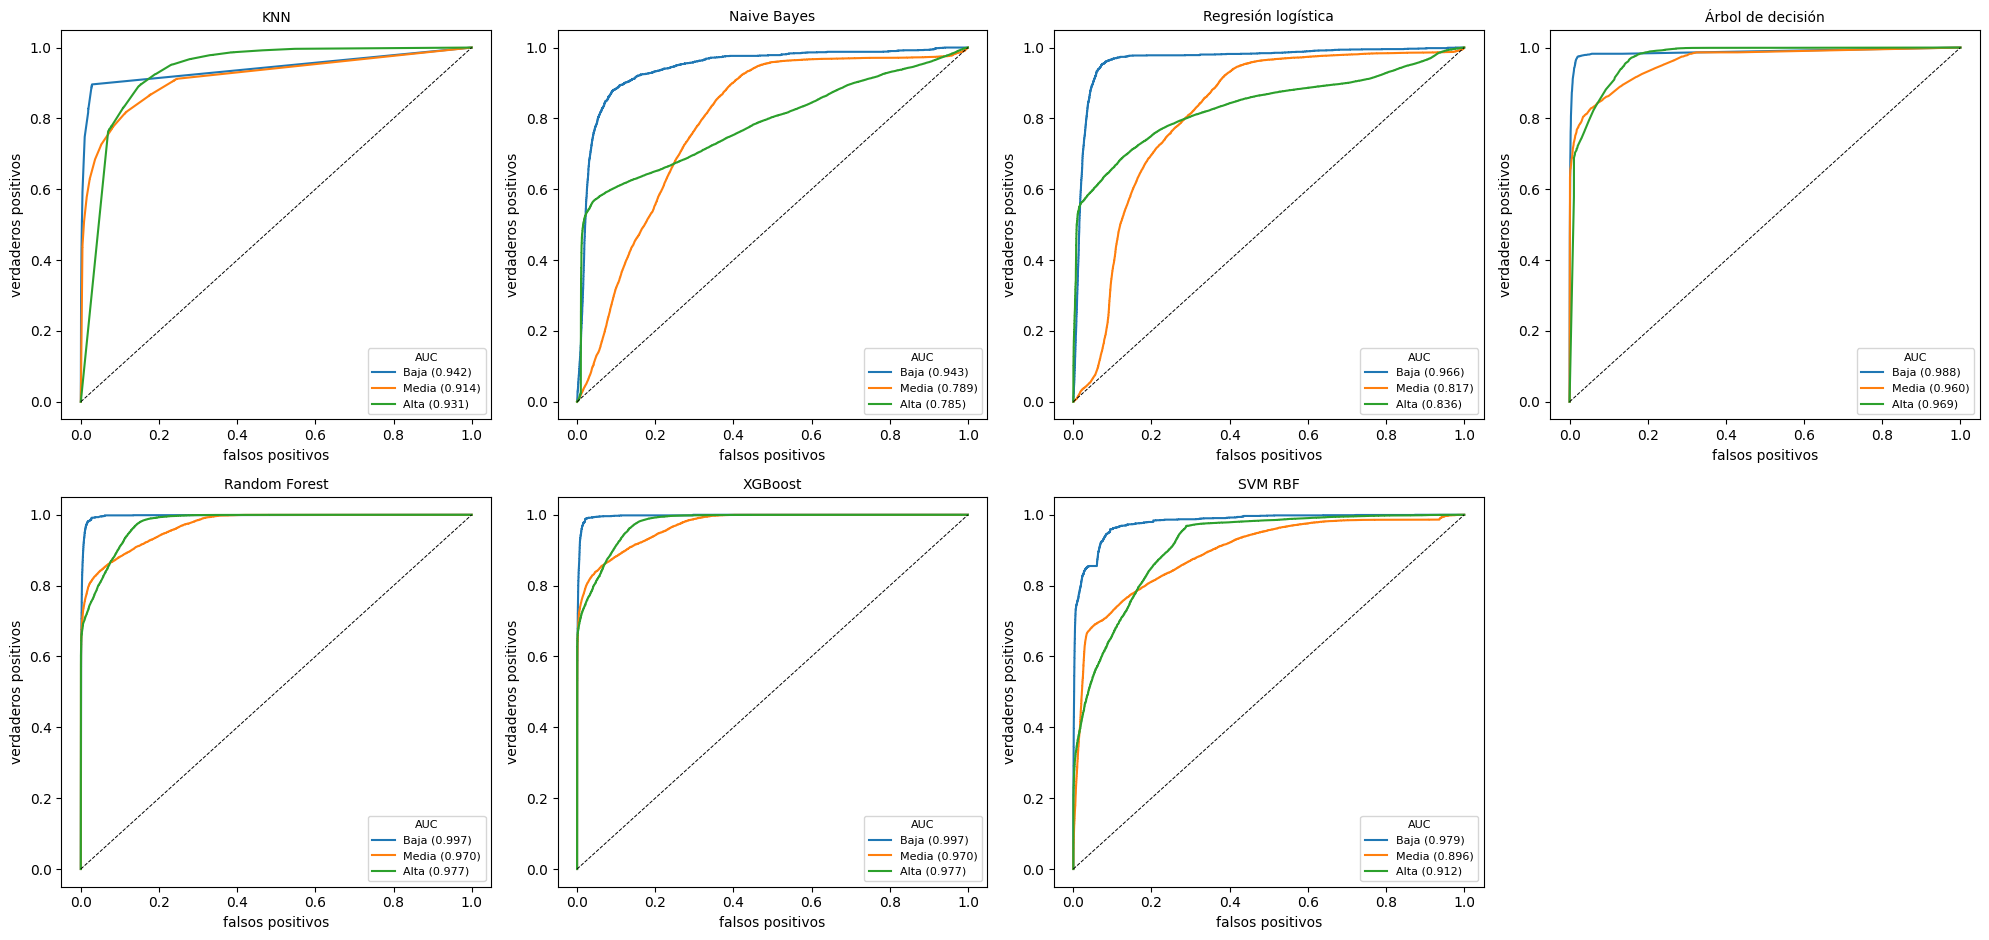

In [6]:
Y = label_binarize(y, classes=[0, 1, 2])
fig, axes = plt.subplots(2, 4, figsize=(20, 9.5))
for ax, m in zip(axes.ravel(), ORDEN):
    p = analisis.oof(mejores.loc[m])["proba"]
    for c, nombre in enumerate(config.CLASES):
        fpr, tpr, _ = roc_curve(Y[:, c], p[:, c])
        ax.plot(fpr, tpr, label=f"{nombre} ({roc_auc_score(Y[:, c], p[:, c]):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=.7); ax.set_title(m, fontsize=10); ax.legend(fontsize=8, title="AUC", title_fontsize=8)
    ax.set_xlabel("falsos positivos"); ax.set_ylabel("verdaderos positivos")
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.tight_layout(); fig.savefig("fig_exp_roc.png", dpi=130, bbox_inches="tight"); plt.show()

## 5. Efecto del balanceo

Promedio sobre los cuatro optimizadores. La pregunta es si crear puntos sintéticos (SMOTE, ADASYN) o pesar las clases (`class_weight`)
ayuda a la clase Baja sin dañar al resto, y qué le hace a la calibración de las probabilidades.

f1_macro                             recall_baja  \
balanceo              adasyn class_weight ninguno  smote      adasyn   
modelo                                                                 
KNN                    0.762          NaN   0.799  0.771       0.692   
Naive Bayes            0.464        0.465   0.578  0.470       0.955   
Regresión logística    0.586        0.629   0.600  0.629       0.949   
Árbol de decisión      0.818        0.855   0.876  0.860       0.874   
Random Forest          0.871        0.882   0.893  0.882       0.915   
XGBoost                0.868        0.878   0.885  0.878       0.913   
SVM RBF                0.735        0.790   0.814  0.789       0.866   

                                                f1_baja                       \
balanceo            class_weight ninguno  smote  adasyn class_weight ninguno   
modelo                                                                         
KNN                          NaN   0.632  0.724   0.674          NaN   0.700   
Naive Bayes                0.955   0.767  0.939   0.185        0.190   0.481   
Regresión logística        0.932   0.420  0.926   0.476        0.507   0.527   
Árbol de decisión          0.893   0.829  0.922   0.800        0.809   0.839   
Random Forest              0.917   0.860  0.924   0.848        0.847   0.860   
XGBoost                    0.901   0.861  0.922   0.843        0.843   0.849   
SVM RBF                    0.763   0.726  0.895   0.730        0.731   0.757   

                           exactitud                                ece  \
balanceo             smote    adasyn class_weight ninguno  smote adasyn   
modelo                                                                    
KNN                  0.685     0.854          NaN   0.893  0.862  0.138   
Naive Bayes          0.198     0.577        0.572   0.713  0.581  0.278   
Regresión logística  0.514     0.662        0.718   0.768  0.716  0.089   
Árbol de decisión    0.817     0.866        0.914   0.929  0.917  0.080   
Random Forest        0.846     0.917        0.930   0.940  0.931  0.027   
XGBoost              0.840     0.915        0.928   0.935  0.929  0.020   
SVM RBF              0.735     0.779        0.863   0.895  0.859  0.112   

                                                 
balanceo            class_weight ninguno  smote  
modelo                                           
KNN                          NaN   0.027  0.120  
Naive Bayes                0.241   0.081  0.262  
Regresión logística        0.068   0.050  0.068  
Árbol de decisión          0.067   0.019  0.063  
Random Forest              0.033   0.016  0.030  
XGBoost                    0.067   0.017  0.033  
SVM RBF                    0.029   0.024  0.038

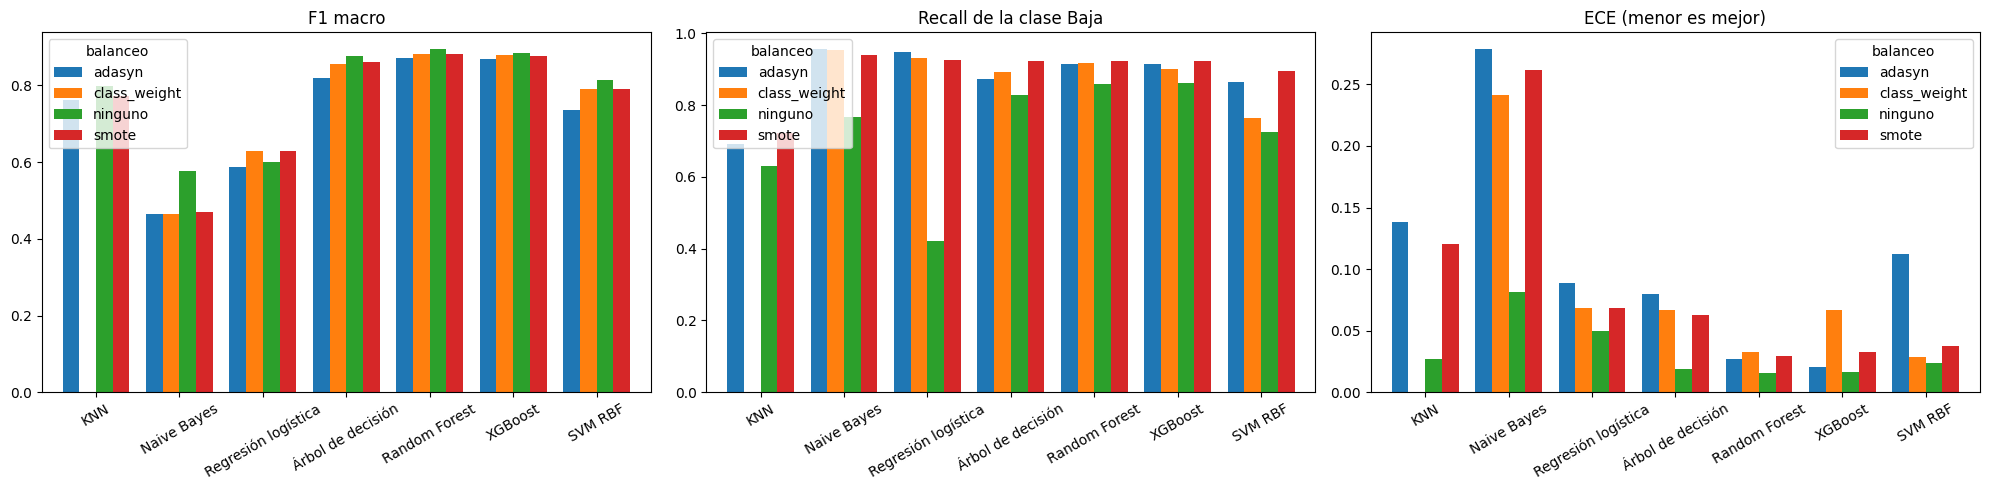

In [7]:
bal = clf.groupby(["modelo", "balanceo"])[["f1_macro", "recall_baja", "f1_baja", "exactitud", "ece"]].mean()
display(bal.unstack("balanceo").reindex(ORDEN).round(3))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, met, titulo in zip(axes, ["f1_macro", "recall_baja", "ece"], ["F1 macro", "Recall de la clase Baja", "ECE (menor es mejor)"]):
    bal[met].unstack("balanceo").reindex(ORDEN).plot.bar(ax=ax, width=.8)
    ax.set_title(titulo); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig("fig_exp_balanceo.png", dpi=130, bbox_inches="tight"); plt.show()

## 6. Calibración

Un modelo está calibrado si, de las plantas a las que les da 80 % de probabilidad, acierta en más o menos el 80 %. Importa porque las
probabilidades se usan para decidir dónde invertir.

El Brier es el error cuadrático medio de las probabilidades y el ECE, la diferencia media entre confianza y exactitud por grupos de confianza (Guo et al., 2017). En los dos, menor es mejor.

Recalibración: Platt (una sigmoide; Platt, 1999) e isotónica (una función monótona por tramos; Zadrozny y Elkan, 2002). Se ajustan sin fuga:
el calibrador de cada pliegue externo se entrena con las predicciones fuera de pliegue de los otros cuatro.

In [8]:
filas, curvas = [], {}
pl = None
for m in ORDEN:
    o = analisis.oof(mejores.loc[m])
    p, pl = o["proba"], o["pliegue"]
    for nombre, q in [("original", p), ("Platt", analisis.recalibrar_cruzado(p, y, pl, "platt")),
                      ("isotónica", analisis.recalibrar_cruzado(p, y, pl, "isotonica"))]:
        filas.append({"modelo": m, "probabilidades": nombre, "Brier": evaluate.brier_multiclase(y, q), "ECE": evaluate.ece(y, q),
                      "F1 macro (argmax)": evaluate.metricas_clf(y, q.argmax(1), None)["f1_macro"]})
        curvas[(m, nombre)] = analisis.confiabilidad(y, q)
cal = pd.DataFrame(filas).set_index(["modelo", "probabilidades"])
cal.round(4)

Brier     ECE  F1 macro (argmax)
modelo              probabilidades                                   
KNN                 original        0.0540  0.0265             0.8008
                    Platt           0.0542  0.0295             0.7987
                    isotónica       0.0533  0.0053             0.8011
Naive Bayes         original        0.1260  0.0715             0.5825
                    Platt           0.1109  0.1099             0.4989
                    isotónica       0.1027  0.0194             0.3056
Regresión logística original        0.1293  0.0548             0.6288
                    Platt           0.0996  0.0766             0.6059
                    isotónica       0.0944  0.0273             0.6282
Árbol de decisión   original        0.0354  0.0124             0.8817
                    Platt           0.0373  0.0320             0.8794
                    isotónica       0.0353  0.0051             0.8843
Random Forest       original        0.0322  0.0132             0.8946
                    Platt           0.0331  0.0163             0.8917
                    isotónica       0.0319  0.0030             0.8945
XGBoost             original        0.0325  0.0145             0.8887
                    Platt           0.0340  0.0240             0.8897
                    isotónica       0.0323  0.0028             0.8869
SVM RBF             original        0.0605  0.0245             0.8152
                    Platt           0.0619  0.0052             0.8136
                    isotónica       0.0606  0.0226             0.8147

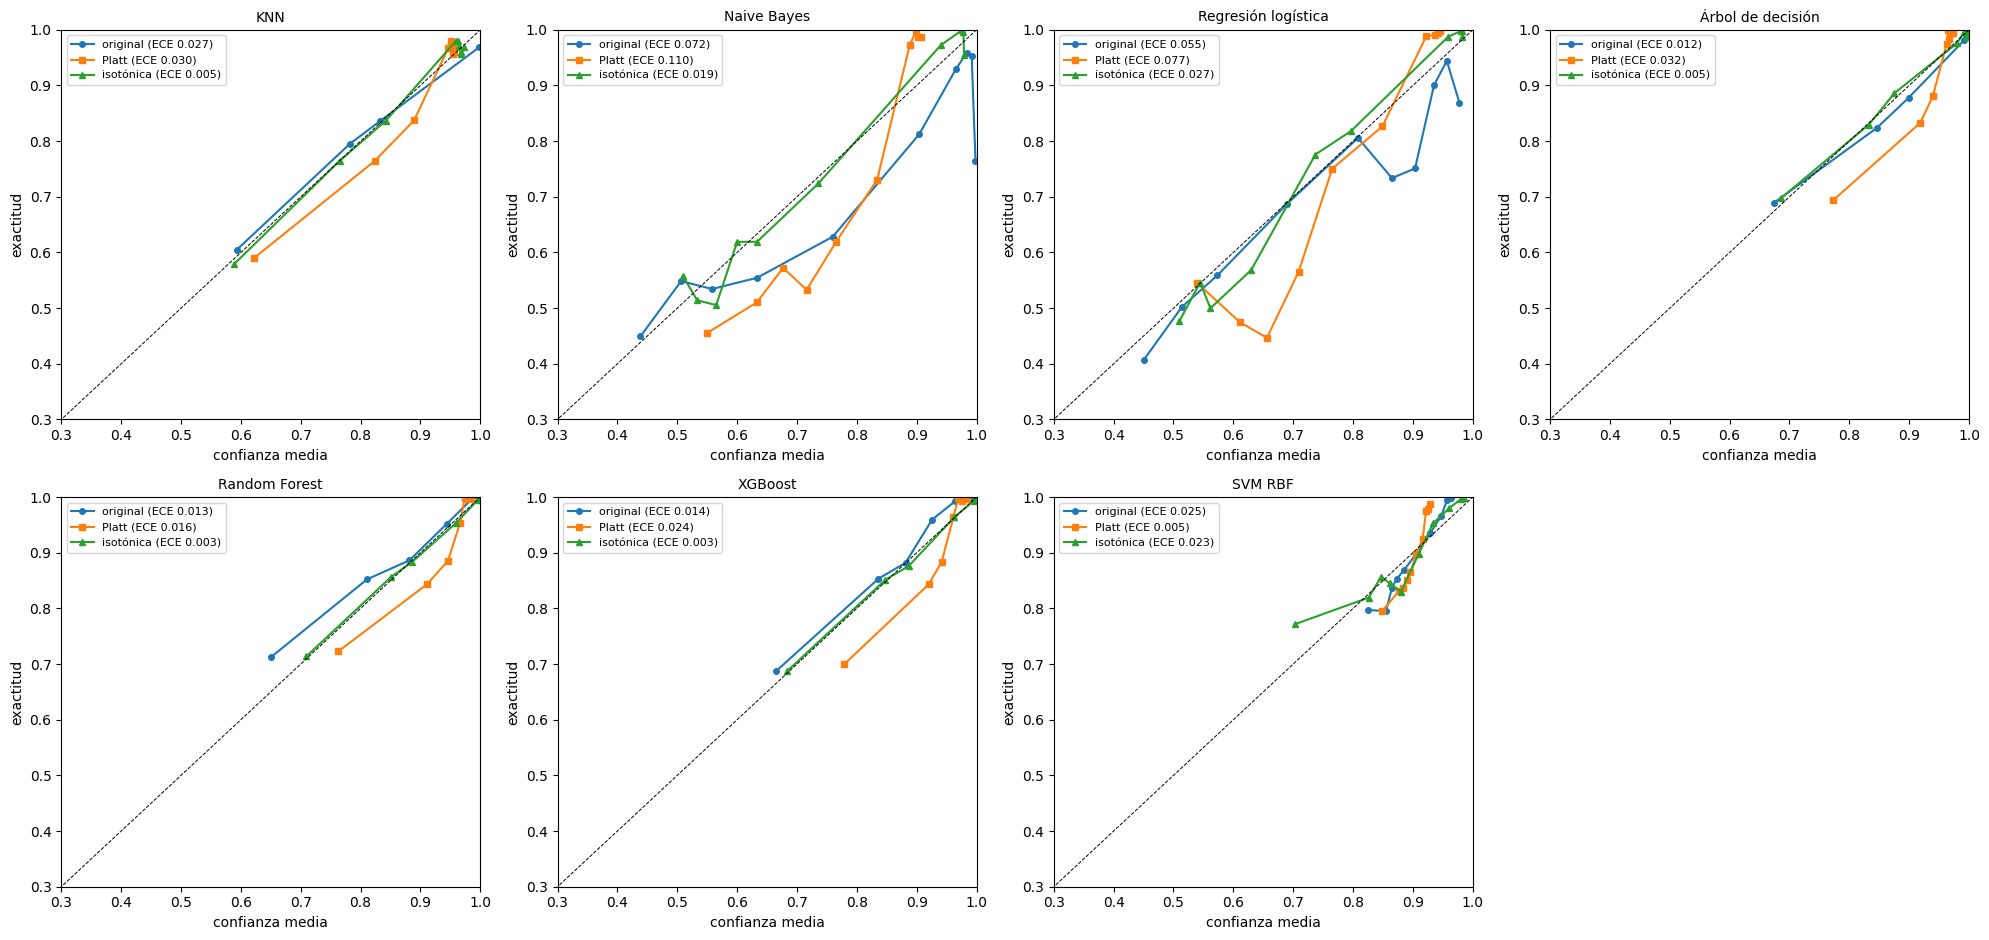

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9.5))
for ax, m in zip(axes.ravel(), ORDEN):
    for nombre, estilo in [("original", "-o"), ("Platt", "-s"), ("isotónica", "-^")]:
        x, f = curvas[(m, nombre)]
        ax.plot(x, f, estilo, ms=4, label=f"{nombre} (ECE {cal.loc[(m, nombre), 'ECE']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=.7); ax.set_xlim(.3, 1); ax.set_ylim(.3, 1)
    ax.set_title(m, fontsize=10); ax.set_xlabel("confianza media"); ax.set_ylabel("exactitud"); ax.legend(fontsize=8)
for ax in axes.ravel()[len(ORDEN):]:
    ax.axis("off")
fig.tight_layout(); fig.savefig("fig_exp_calibracion.png", dpi=130, bbox_inches="tight"); plt.show()

## 7. Estabilidad de los hiperparámetros elegidos

Si cada pliegue externo elige valores muy distintos, el modelo es sensible a qué bloques le tocan, o el puntaje es plano en esa región
del espacio y da igual el valor.

In [10]:
mejor = mejores.puntaje_interno.idxmax()
print("Modelo con mejor puntaje interno:", mejor, "|", mejores.loc[mejor, "balanceo"], "|", mejores.loc[mejor, "optimizador"])
analisis.params_por_pliegue(maestra, mejores.loc[mejor]).round(4)

Modelo con mejor puntaje interno: Random Forest | ninguno | aleatoria


,n_estimators,max_features,min_samples_leaf,max_samples
pliegue,,,,
0,96,0.6213,2,0.8710
1,116,0.8494,15,0.3811
2,186,0.7297,3,0.9723
3,168,0.6984,16,0.8027
4,96,0.6213,2,0.8710


## 8. Interpretación

Los tres modelos de árboles quedan arriba: Random Forest (F1 macro 0.894), XGBoost (0.888) y el árbol de decisión (0.881), con AUC de 0.97 o más. Les siguen el SVM RBF (0.814) y KNN (0.799). La regresión logística (0.629) y Naive Bayes (0.580) quedan muy por debajo. Dentro de un mismo modelo el optimizador casi no cambia el resultado: en Random Forest las cuatro búsquedas dan entre 0.893 y 0.894.

El balanceo no mejoró el F1 macro. Sin balanceo sale el mejor valor en KNN, Naive Bayes, el árbol, Random Forest, XGBoost y el SVM; la excepción es la regresión logística, que pasa de 0.600 a 0.629 con `class_weight` o SMOTE. Las tres técnicas sí suben el recall de la clase Baja (en Random Forest, de 0.860 a entre 0.915 y 0.924), pero con más falsos positivos, así que el F1 de Baja baja un poco (0.860 sin balanceo y entre 0.846 y 0.848 con balanceo). También empeoran la calibración: el ECE de Random Forest sube de 0.016 a entre 0.027 y 0.033.

Los árboles salen bien calibrados sin tocarlos (ECE de 0.012 a 0.015 con las predicciones fuera de pliegue). La recalibración isotónica los baja a entre 0.003 y 0.005, y la de Platt los empeora. En Naive Bayes y en la regresión logística la isotónica reduce el ECE (de 0.072 a 0.019 y de 0.055 a 0.027), pero en Naive Bayes el F1 cae de 0.583 a 0.306: sirve para mejorar las probabilidades y no para decidir la clase.

Los hiperparámetros de Random Forest cambian bastante entre pliegues (de 96 a 186 árboles y de 2 a 16 muestras por hoja) sin que cambie el puntaje, así que el puntaje es casi plano cerca del óptimo.

## Referencias

- Cawley, G. C. y Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079-2107.
- Chawla, N. V., Bowyer, K. W., Hall, L. O. y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357. https://doi.org/10.1613/jair.953
- Guo, C., Pleiss, G., Sun, Y. y Weinberger, K. Q. (2017). On calibration of modern neural networks. En *Proceedings of ICML* (PMLR 70, pp. 1321-1330).
- He, H., Bai, Y., Garcia, E. A. y Li, S. (2008). ADASYN: Adaptive synthetic sampling approach for imbalanced learning. En *2008 IEEE IJCNN* (pp. 1322-1328). https://doi.org/10.1109/IJCNN.2008.4633969
- Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. En *Advances in Large Margin Classifiers* (pp. 61-74). MIT Press.
- Zadrozny, B. y Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates. En *Proceedings of the 8th ACM SIGKDD* (pp. 694-699). https://doi.org/10.1145/775047.775151